# 鸢尾花分类实验




# 1. 实验介绍   
## 1.1 实验目的 
1. 掌握前馈神经网络涉及到的基础概念，包括：[神经元](https://paddlepedia.readthedocs.io/en/latest/tutorials/deep_learning/basic_concepts/neuron.html)、[激活函数](https://paddlepedia.readthedocs.io/en/latest/tutorials/deep_learning/activation_functions/Activation_Function.html)、[损失函数](https://paddlepedia.readthedocs.io/en/latest/tutorials/deep_learning/loss_functions/index.html)、[单层感知机](https://paddlepedia.readthedocs.io/en/latest/tutorials/deep_learning/basic_concepts/single_layer_perceptron.html)、[多层感知机](https://paddlepedia.readthedocs.io/en/latest/tutorials/deep_learning/basic_concepts/multilayer_perceptron.html)；
2. 掌握前馈神经网络的架构的设计原理以及构建流程；
3. 掌握如何使用 PyTorch 构建前馈神经网络；

## 1.2 实验内容 

鸢尾花分类任务是入门深度学习的基础实验之一，为了让大家更好地掌握前馈神经网络的结构及原理，本实验基于前馈神经网络完成鸢尾花分类任务。前馈神经网络的隐藏层可以接收输入层所有神经元传递来的信息，经过加工处理将信息传递给输出层的所有神经元，从而模拟复杂的非线性函数，实现鸢尾花分类任务。

本实验使用经典数据集 Iris，使用 **PyTorch** 构建前馈神经网络，通过鸢尾花分类掌握深度学习建模流程及前馈神经网络的结构与原理。

## 1.3 实验环境
本实验使用 **Python 3** 与 **PyTorch**（及 NumPy、sklearn）。安装：`pip install torch numpy scikit-learn`。

## 1.4 实验设计

本实验的实现方案如 **图1** 所示，先将花卉数据输入模型，通过前馈神经网络提取每条数据对应的特征，获取特征表示。然后经过分类器获取花卉所属类别的概率值。在训练阶段，通过模型输出的概率值与样本的真实标签构建损失函数，从而进行模型训练；在推理阶段，选择概率最大的类别作为最终的预测值输出。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/4222a088c2664d3e81a486aa3ddbd8d5f1dbf16c773d4da38dafe6bee9b40895" width = "900"></center>
<center><br>图1 实现方案</br></center>


# 2. 实验详细实现 

鸢尾花分类实验流程如 **图2** 所示，主要分为以下7个部分：
1. **数据处理**：根据网络接收的数据格式，完成相应的预处理操作，保证模型正常读取；
1. **模型构建**：设计自定义的前馈网络结构；
1. **训练配置**：实例化模型，指定模型采用的寻解算法（优化器）；
1. **模型训练**：执行多轮训练不断调整参数，以达到较好的效果；
1. **模型保存**：保存模型参数；
1. **模型评估**：对训练好的模型进行评估测试，观察准确率；
1. **模型推理**：使用一条鸢尾花数据验证模型分类效果；


<center><img src="https://ai-studio-static-online.cdn.bcebos.com/af4935248f6f4db9a948913b6bb8a23a8ab1b7fba21f4648a2b8e9165fbd3170" width = "700"></center>
<center><br>图2 实验流程</br></center>
<br></br>


## 2.1 数据处理

本次实验使用鸢尾花数据集，用 PyTorch 构建前馈神经网络，实现鸢尾花分类任务。

### 2.1.1 数据集介绍

Iris 数据集，也称为鸢尾花数据集。该数据集包含了3种鸢尾花类别（Setosa，Versicolour，Virginica），每种类别有50个样本，共计150个样本。其中，每个样本中包含了4个属性：花萼长度、花萼宽度、花瓣长度以及花瓣宽度，而我们需要做的就是通过这4个属性来判断该样本属于三个鸢尾花种类中的哪一类。


**鸢尾花属性**
<center>
  
|属性1   |属性2   |属性3    |属性4    |
|:--:    |:--:   |:--:    |:--:     |
|sepal_length |sepal_width|petal_length|petal_width|
|花萼长度      |花萼宽度|花瓣长度|花瓣宽度|
</center>


**鸢尾花类别**
<center>
  
|英文名            |中文名      |标签    |
|:--:             |:--:        |:--:    |
|Setosa Iris      |狗尾草鸢尾   |  0
|Versicolour Iris |杂色鸢尾     |  1
|Viginaica Iris   |弗吉尼亚鸢尾  |  2
  
</center>

**鸢尾花属性类别对应预览**

<center>
  
|sepal_length |sepal_width|petal_length|petal_width| species 
|:--:         |:--:       |:--:        |:--:       |:--:       |
|5.1	      |3.5	      |1.4	       |0.2	       |setosa
|4.9	      |3	      |1.4	       |0.2	       |setosa
|4.7	      |3.2	      |1.3	       |0.2	       |setosa
|...          |...        |...         |...        |...        |

</center>

### 2.1.2 数据获取
在本次实验中，使用 sklearn 中提供的 API 接口获取鸢尾花数据集，实现代码如下：

****

**说明：**

sklearn 是常用的第三方机器学习模块，内部封装了许多的机器学习算法以及多个常用数据集。通过调用 API 可以很方便地进行使用。

****

In [1]:
#使用sklearn提供的datasets API导入鸢尾花数据集
from sklearn.datasets import load_iris
# 获取鸢尾花的属性信息
x = load_iris().data
# 获取鸢尾花的标签信息
y = load_iris().target
# 查看数据集
print(x)
# 查看数据集中的样本个数
print(len(x))

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

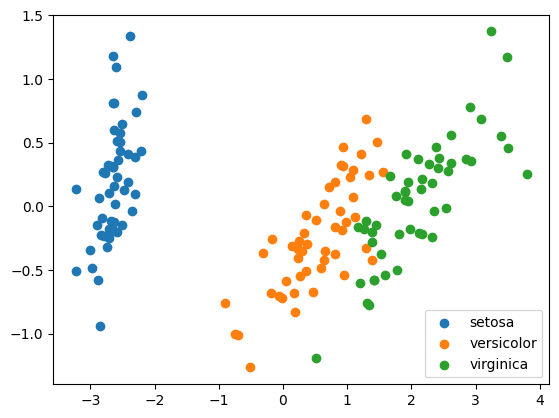

In [2]:
# 将数据下降至二维，观察其分布
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2) # 实例化
pca = pca.fit(x)          # 进行无监督学习
x_dr = pca.transform(x)   # 获取降维后数据

plt.figure()
for i in range(3):
    plt.scatter(x_dr[y==i][:, 0], 
                x_dr[y==i][:, 1], 
                label=load_iris()['target_names'][i])
plt.legend()
plt.show()

从上图中可以看出, 三类降维数据在二维空间线性不可分, 因此需要借助神经网络的非线性进行分类。

### 2.1.3 数据集划分

将数据集划分成训练集和测试集，其中训练集用于确定模型的参数，测试集用于评判模型的效果。在本案例中，将80%的数据用于模型训练，20%的数据用于模型验证。实现代码如下：

In [3]:
# coding=utf-8
# 导入环境
import os
import random
import math
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# 在notebook中使用matplotlib.pyplot绘图时，需要添加该命令进行显示


from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from sklearn import preprocessing


class IrisData(object):
    def __init__(self, use_min_max=False):
        self.x = load_iris().data
        self.y = load_iris().target
        self.x = np.array(self.x, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.int64)

        if use_min_max:
            min_max_scaler = preprocessing.MinMaxScaler()
            self.x = min_max_scaler.fit_transform(self.x)

        sample_list = list(range(len(self.x)))
        random.shuffle(sample_list)

        # 80% 的数据用于训练
        self.train_size = int(len(self.x) * 0.8)
        # 剩下 20% 数据用于测试
        self.test_size = len(self.x) - self.train_size

        self.train_list = sample_list[:self.train_size]
        self.test_list = sample_list[self.train_size:]

    def __call__(self, *args, **kwargs):
        train_x = self.x[self.train_list]
        train_y = self.y[self.train_list]
        test_x = self.x[self.test_list]
        test_y = self.y[self.test_list]
        return (train_x, train_y), (test_x, test_y)

### 2.1.4 数据读取

通过继承 PyTorch 的 `torch.utils.data.Dataset` 来构建数据读取器，用于每次获取一个样本的特征与标签。

In [4]:
# 构建数据读取器（PyTorch Dataset）
class Generate(torch.utils.data.Dataset):
    def __init__(self, data):
        self.x, self.y = data
        self.x = torch.tensor(self.x, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.long)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

    def __len__(self):
        return len(self.y)

使用 PyTorch 的 `torch.utils.data.DataLoader` 按 batch 加载数据。

关键参数：`batch_size` 每批样本数；`shuffle` 是否打乱；`num_workers` 子进程数（可选）。

构建数据迭代器代码如下：

In [5]:
train_data, test_data = IrisData(use_min_max=True)()
train_generate = Generate(data=train_data)
train_dataloader = DataLoader(train_generate, batch_size=4, shuffle=True)

test_generate = Generate(data=test_data)
test_dataloader = DataLoader(test_generate, batch_size=4, shuffle=False)# 第一个参数是数据集，第二个参数是batch_size，第三个参数是是否打乱数据


# 迭代数据读取器，获取一个batch的数据
for x, y in train_dataloader:
    print(x, y)
    break

tensor([[0.4444, 0.5000, 0.6441, 0.7083],
        [0.4167, 0.2917, 0.6949, 0.7500],
        [0.8056, 0.5000, 0.8475, 0.7083],
        [0.5556, 0.2917, 0.6610, 0.7083]]) tensor([1, 2, 2, 2])


至此，完成了数据准备的相关工作，接下来将处理好的数据输入到神经网络，应用到具体算法上。

## 2.2 模型构建 

在完成数据集准备的准备工作以后，需要设计训练模型，本次实验采用的模型结构是前馈神经网络，结构如 **图4** 所示：

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/57b3f70d1a4849db93a6e00cbf0a750420852c56aa8644759a3ac1206c933418" width = "700"></center>
<center><br>图4 网络结构</br></center>
<br></br>

本实验构建了一个简单的前馈神经网络，该网络由`输入层`、`隐藏层` 和 `输出层`构成，这是一个2层结构。

由于鸢尾花的分类由四种属性决定，且鸢尾花有三种类别。因此该网络的输入层由四个神经元组成，输出层由三个神经元组成。其中每层神经元只和相邻层神经元相连，即隐藏层的每个神经元只接收来自输入层的四个属性信息，经过 Sigmoid 激活函数之后将信息传递给输出层，最后输出层后连接 Softmax 函数，计算出每个类别的预测概率。

**** 
**说明：**

神经元模型是神经网络中最基本的组成成分，这一概念来源于生物神经网络中，通过电位变化表示“兴奋”的生物神经元。在深度学习领域，一个神经元其实是一个计算单元。每层神经元只和相邻神经元相连，即每层神经元只接收相邻前序神经网络中神经元所传来的信息，只给相邻的后续神经层中的神经元传递信息。在前馈神经网络中，同一层的神经元之间没有任何连接。

神经网络中使用非线性函数作为激活函数，通过对多个非线性函数进行组合，实现对输入信息的非线性变换。
**** 

使用 PyTorch 的 `nn.Module` 子类定义网络：`__init__()` 中声明层，`forward()` 中写前向计算。

网络结构如下：

In [6]:
# 定义前馈神经网络（PyTorch nn.Module）
class MultiFC(nn.Module):
    def __init__(self):
        super(MultiFC, self).__init__()
        self.fc1 = nn.Linear(4, 3)
        self.act = nn.Sigmoid()
        self.fc2 = nn.Linear(3, 3)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)  # 输出 logits，与 F.cross_entropy 配合使用
        return x

上述网络使用 PyTorch 的 `nn.Linear`、`nn.Sigmoid`、`nn.Softmax` 等 API，详见 [PyTorch 文档](https://pytorch.org/docs/stable/nn.html)。

## 2.3 训练配置


先获取并加载鸢尾花数据，再声明定义好的前馈神经网络模型实例，最后分别定义好优化器和损失函数。本实验使用的优化器算法为Adam，学习率设置为0.01，损失函数使用交叉熵损失。

In [7]:
lr = 0.01     # 学习率learning rate大小
output_dir = './models'   # 模型存放的目录

# 获取鸢尾花的训练集和测试集
train_data, test_data = IrisData(use_min_max=True)()
train_generate = Generate(data=train_data)
train_dataloader = DataLoader(train_generate, batch_size=32, shuffle=True)
test_generate = Generate(data=test_data)
test_dataloader = DataLoader(test_generate, batch_size=32)

model = MultiFC()
opt = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = F.cross_entropy

****
**说明：**

交叉熵是信息论中的重要概念，主要用来度量两个概率分布的差异，假定 $p$ 和 $q$ 是数据 $x$ 的两个概率分布，通过 $q$ 来表示 $p$ 的交叉熵可如下计算：
$$
H\left( p,q \right) =-\sum_x{p\left( x \right) \cdot \log q\left( x \right)}
$$
交叉熵刻画了两个概率分布之间的距离，旨在描绘通过概率分布 $q$ 来表达概率分布 $p$ 的困难程度。根据公式不难理解，交叉熵越小，两个概率分布 $p$ 和 $q$ 越接近。
****

## 2.4 模型训练
本次实验总共训练了 500个epoch，每个 epoch 都需要在训练集与验证集上运行，并打印出训练集上的loss 和模型在训练和验证集上的准确率，并且每一轮训练完成之后都对模型进行保存。

***
**说明：**

训练的轮次会直接影响到模型训练的效果，同学们在演示过程中如果考虑到训练时长问题，可以将epoch稍微调小，快速完成训练过程。同学们可以动手对比一下当设置不同的epoch时，模型预测的准确率如何变化。
***

In [8]:
class Trainer(object):
    def __init__(self, output_dir, model, optimizer, loss_fn):
        self.output_dir = output_dir
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn

    def save(self, epoch):
        """保存模型"""
        if os.path.exists(self.output_dir):
            pass
        else:
            os.mkdir(self.output_dir)
        model_path = os.path.join(self.output_dir, 'iris_{}.pt'.format(epoch))
        opt_path = os.path.join(self.output_dir, 'iris_{}_opt.pt'.format(epoch))
        torch.save(self.model.state_dict(), model_path)
        torch.save(self.optimizer.state_dict(), opt_path)

    def train_step(self, data):
        x, y = data
        pred = self.model(x)
        loss = self.loss_fn(pred, y)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss

    def train_epoch(self, dataloader, epoch):
        self.model.train()
        for i, data in enumerate(dataloader):
            loss = self.train_step(data)
            print('epoch:{}, step:{}, loss:{}'.format(epoch, i, loss.item()))

    def val_epoch(self, dataloader):
        self.model.eval()
        acc = []
        with torch.no_grad():
            for i, data in enumerate(dataloader):
                x, y = data
                pred = self.model(x)
                pred = pred.argmax(dim=1)
                acc.extend((pred == y).float().cpu().numpy().tolist())
        return np.array(acc).mean()

    def train(self, epochs, train_dataloader, test_dataloader):
        for i in range(epochs):
            self.train_epoch(train_dataloader, i)
            train_acc = self.val_epoch(train_dataloader)
            test_acc = self.val_epoch(test_dataloader)
            print('the train acc is {}, test acc is {}'.format(train_acc, test_acc))

            # 保存模型
            self.save(i)   


In [9]:
# 同学们可以依据自己的情况调整epoch大小
epoch = 5000   # 模型训练的轮数
output_dir = './models'   # 模型存放的目录

# 实例化训练器
trainer = Trainer(output_dir=output_dir,
                    model=model,
                    optimizer=opt,
                    loss_fn=loss_fn)
# 启动训练
trainer.train(epoch, train_dataloader, test_dataloader)

epoch:0, step:0, loss:1.1274418830871582
epoch:0, step:1, loss:1.0875862836837769
epoch:0, step:2, loss:1.1053653955459595
epoch:0, step:3, loss:1.1131466627120972
the train acc is 0.325, test acc is 0.36666666666666664
epoch:1, step:0, loss:1.111311674118042
epoch:1, step:1, loss:1.0949946641921997
epoch:1, step:2, loss:1.093685269355774
epoch:1, step:3, loss:1.1005512475967407
the train acc is 0.49166666666666664, test acc is 0.4666666666666667
epoch:2, step:0, loss:1.089892864227295
epoch:2, step:1, loss:1.0933278799057007
epoch:2, step:2, loss:1.0803654193878174
epoch:2, step:3, loss:1.1191922426223755
the train acc is 0.39166666666666666, test acc is 0.23333333333333334
epoch:3, step:0, loss:1.097971796989441
epoch:3, step:1, loss:1.0888786315917969
epoch:3, step:2, loss:1.0918549299240112
epoch:3, step:3, loss:1.0682073831558228
the train acc is 0.375, test acc is 0.16666666666666666
epoch:4, step:0, loss:1.078578233718872
epoch:4, step:1, loss:1.070105791091919
epoch:4, step:2, 

##  2.5 模型保存
在 Trainer 类中使用 `torch.save()` 保存模型参数与优化器状态。

In [10]:
def save(self, epoch):
	"""保存模型"""
	if os.path.exists(self.output_dir):
		pass
	else:
		os.mkdir(self.output_dir)
	model_path = os.path.join(self.output_dir, 'iris_{}.pdparams'.format(epoch))
	opt_path = os.path.join(self.output_dir, 'iris_{}.pdopt'.format(epoch))
	torch.save(self.model.state_dict(), model_path)
	torch.save(self.optimizer.state_dict(), opt_path)

使用 `torch.save(obj, path)` 保存模型或优化器状态。

关键参数含义如下：
* obj (Object) – 要保存的对象实例。
* path (str) – 保存对象实例的路径。如果存储到当前路径，输入的path字符串将会作为保存的文件名。


##  2.6 模型评估
使用验证数据对训练好的模型进行评估，代码如下。

In [11]:
def eval():
    model_path = './models/iris_499.pt'
    model = MultiFC()
    model.load_state_dict(torch.load(model_path))
    model.eval()
    acc = []
    with torch.no_grad():
        for i, data in enumerate(test_dataloader):
            x, y = data
            pred = model(x).argmax(dim=1)
            acc.extend((pred == y).float().cpu().numpy().tolist())
    print('the model acc is {}'.format(np.array(acc).mean()))

eval()

the model acc is 1.0


## 2.7 模型推理
接下来展示如何加载训练好的模型，并使用测试集中的数据进行推理测试。

In [12]:
class Inference(object):
    def __init__(self, model_path, model):
        self.model_path = model_path
        self.model = model
        self.load()

    def load(self):
        self.model.load_state_dict(torch.load(self.model_path))

    def __call__(self, x):
        self.model.eval()
        with torch.no_grad():
            output = self.model(x)
        return output.argmax(dim=1).cpu().numpy()


def main():
    model_path = './models/iris_499.pt'
    model = MultiFC()
    infer = Inference(model_path=model_path, model=model)
    _, test_data = IrisData(use_min_max=True)()
    test_generate = Generate(data=test_data)
    test_dataloader = DataLoader(test_generate, batch_size=1)
    for i, (x, y) in enumerate(test_dataloader):
        pred = infer(x)
        print('the true val is {} pred val is {}'.format(y.item(), pred[0]))
        if i > 5:
            break

main()

the true val is 1 pred val is 1
the true val is 0 pred val is 0
the true val is 2 pred val is 2
the true val is 1 pred val is 1
the true val is 2 pred val is 2
the true val is 2 pred val is 2
the true val is 1 pred val is 1


# 3. 实验总结
本章分享了基于 PyTorch 的鸢尾花分类案例，涵盖数据处理、前馈神经网络构建与训练、模型保存与推理。读者可在本案例基础上扩展为其他多分类任务。

# 4. 作业或思考题


1. **二分类激活函数**：Softmax 函数用于多分类任务，处理二分类任务时应使用什么函数？请说明该函数的作用及其输出区间的含义。

2. **过拟合的应对**：若训练集准确率高而测试集准确率明显较低，说明模型出现过拟合。请列举至少三种缓解过拟合的方法，并简要说明各自的原理。

3. **编程作业(选做)** 基于本案例的描述，请使用数据集 MNIST 完成手写数字识别任务。

## 思考题答案

### 1. 二分类激活函数

处理二分类任务时应使用 **Sigmoid 函数**。

**函数公式**：
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

**函数作用**：Sigmoid 函数将任意实数输入映射到 (0, 1) 区间，输出值可以直接解释为概率。

**输出区间含义**：
- 输出值表示样本属于正类（类别1）的概率
- 输出值范围 (0, 1)：接近 0 表示负类，接近 1 表示正类
- 通常以 0.5 为阈值：输出 ≥ 0.5 判定为正类，< 0.5 判定为负类

**与 Softmax 的关系**：对于二分类，Sigmoid 等价于 Softmax 的特例（当类别数为2时，两者数学上等价）。

### 2. 过拟合的应对方法

若训练集准确率高而测试集准确率明显较低，说明模型出现过拟合。以下是三种缓解过拟合的方法：

| 方法 | 原理说明 |
|------|----------|
| **Dropout（随机失活）** | 在训练过程中随机"丢弃"一部分神经元（将其输出置零），迫使网络不依赖特定神经元，增强模型的泛化能力。每次训练相当于训练一个不同的子网络，最终模型相当于多个子网络的集成。 |
| **正则化（L1/L2）** | 在损失函数中添加权重惩罚项（如 L2 范数 $\lambda \sum w_i^2$），限制权重过大，使模型参数更小更平滑，降低模型复杂度，防止模型过度拟合训练数据的噪声。 |
| **数据增强（Data Augmentation）** | 通过旋转、翻转、缩放、裁剪、添加噪声等方式从原始数据生成更多训练样本，增加数据多样性，让模型学习更加鲁棒的特征，减少对特定样本的依赖。 |

**其他常用方法**：
- **早停法（Early Stopping）**：监控验证集损失，当验证集性能不再提升时提前停止训练
- **减小模型复杂度**：减少网络层数或神经元数量，降低模型容量

# 5. 编程作业：MNIST手写数字识别

基于本案例的前馈神经网络结构，使用MNIST数据集完成手写数字识别任务。

**MNIST数据集简介**：
- 包含70,000张手写数字图像（60,000训练集 + 10,000测试集）
- 图像尺寸：28×28灰度图像
- 类别：0-9共10个数字类别

In [20]:
# 5.1 环境配置与数据加载

import os
import random
import numpy as np
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 设置随机种子，保证可复现性
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

使用设备: cpu


In [21]:
# 定义数据预处理：将图像转为张量并归一化
transform = transforms.Compose([
    transforms.ToTensor(),  # 转为张量，同时将像素值从 [0,255] 归一化到 [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # 使用MNIST的均值和标准差进行标准化
])

# 下载并加载MNIST数据集
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 创建数据加载器
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集样本数: {len(train_dataset)}")
print(f"测试集样本数: {len(test_dataset)}")
print(f"图像形状: {train_dataset[0][0].shape}")
print(f"类别数: {len(train_dataset.classes)}")

100.0%
100.0%
100.0%
100.0%

训练集样本数: 60000
测试集样本数: 10000
图像形状: torch.Size([1, 28, 28])
类别数: 10


## 5.2 模型构建

构建前馈神经网络用于MNIST手写数字识别：

**网络结构**：
- 输入层：28×28 = 784 个神经元（图像展平）
- 隐藏层1：256个神经元，使用ReLU激活函数
- 隐藏层2：128个神经元，使用ReLU激活函数
- 输出层：10个神经元（对应0-9十个数字）

**设计要点**：
- 使用ReLU激活函数代替Sigmoid，收敛更快
- 添加Dropout层防止过拟合（丢弃率0.2）
- 输出层不使用激活函数，配合cross_entropy损失（内部包含Softmax）

In [22]:
# 定义前馈神经网络
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        # 输入层到隐藏层1：784 -> 256
        self.fc1 = nn.Linear(28 * 28, 256)
        # 隐藏层1到隐藏层2：256 -> 128
        self.fc2 = nn.Linear(256, 128)
        # 隐藏层2到输出层：128 -> 10
        self.fc3 = nn.Linear(128, 10)
        # 激活函数
        self.relu = nn.ReLU()
        # Dropout层，防止过拟合
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # 展平图像：[batch, 1, 28, 28] -> [batch, 784]
        x = x.view(-1, 28 * 28)
        
        # 第一层
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        # 第二层
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        # 输出层（不使用激活函数，交叉熵损失内部包含Softmax）
        x = self.fc3(x)
        return x

# 实例化模型并移至设备
model = MNISTNet().to(device)
print(model)

MNISTNet(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


## 5.3 训练配置

配置优化器和损失函数：
- **优化器**：Adam，学习率 0.001
- **损失函数**：交叉熵损失（cross_entropy）

In [23]:
lr = 0.001  # 学习率
output_dir = './mnist_models'  # 模型保存目录

# 定义优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = F.cross_entropy

## 5.4 模型训练

定义训练器类，包含训练、评估和模型保存功能。

In [24]:
class MNISTTrainer(object):
    def __init__(self, output_dir, model, optimizer, loss_fn, device):
        self.output_dir = output_dir
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.device = device
        self.train_losses = []
        self.train_accs = []
        self.test_accs = []

    def save(self, epoch):
        """保存模型"""
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
        model_path = os.path.join(self.output_dir, f'mnist_{epoch}.pt')
        torch.save(self.model.state_dict(), model_path)

    def train_step(self, data):
        """单步训练"""
        x, y = data
        x, y = x.to(self.device), y.to(self.device)
        pred = self.model(x)
        loss = self.loss_fn(pred, y)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def train_epoch(self, dataloader, epoch):
        """训练一个epoch"""
        self.model.train()
        total_loss = 0
        for i, data in enumerate(dataloader):
            loss = self.train_step(data)
            total_loss += loss
        return total_loss / len(dataloader)

    def evaluate(self, dataloader):
        """评估模型准确率"""
        self.model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data in dataloader:
                x, y = data
                x, y = x.to(self.device), y.to(self.device)
                pred = self.model(x).argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)
        return correct / total

    def train(self, epochs, train_dataloader, test_dataloader):
        """完整训练流程"""
        best_acc = 0.0
        for epoch in range(epochs):
            # 训练
            avg_loss = self.train_epoch(train_dataloader, epoch)
            self.train_losses.append(avg_loss)
            
            # 评估
            train_acc = self.evaluate(train_dataloader)
            test_acc = self.evaluate(test_dataloader)
            self.train_accs.append(train_acc)
            self.test_accs.append(test_acc)
            
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Train Acc: {train_acc*100:.2f}%, Test Acc: {test_acc*100:.2f}%')
            
            # 保存最佳模型
            if test_acc > best_acc:
                best_acc = test_acc
                self.save(epoch)
        
        print(f'\n训练完成！最佳测试集准确率: {best_acc*100:.2f}%')

In [25]:
# 实例化训练器并开始训练
trainer = MNISTTrainer(
    output_dir=output_dir,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device
)

epochs = 10  # MNIST通常10个epoch即可达到98%以上准确率
trainer.train(epochs, train_dataloader, test_dataloader)

Epoch [1/10], Loss: 0.2787, Train Acc: 96.73%, Test Acc: 96.49%
Epoch [2/10], Loss: 0.1287, Train Acc: 97.75%, Test Acc: 97.13%
Epoch [3/10], Loss: 0.1008, Train Acc: 98.37%, Test Acc: 97.55%
Epoch [4/10], Loss: 0.0838, Train Acc: 98.62%, Test Acc: 97.86%
Epoch [5/10], Loss: 0.0738, Train Acc: 98.72%, Test Acc: 97.71%
Epoch [6/10], Loss: 0.0650, Train Acc: 98.94%, Test Acc: 97.70%
Epoch [7/10], Loss: 0.0599, Train Acc: 99.15%, Test Acc: 98.01%
Epoch [8/10], Loss: 0.0535, Train Acc: 99.33%, Test Acc: 97.91%
Epoch [9/10], Loss: 0.0516, Train Acc: 99.21%, Test Acc: 97.98%
Epoch [10/10], Loss: 0.0471, Train Acc: 99.44%, Test Acc: 98.20%

训练完成！最佳测试集准确率: 98.20%


## 5.5 训练过程可视化

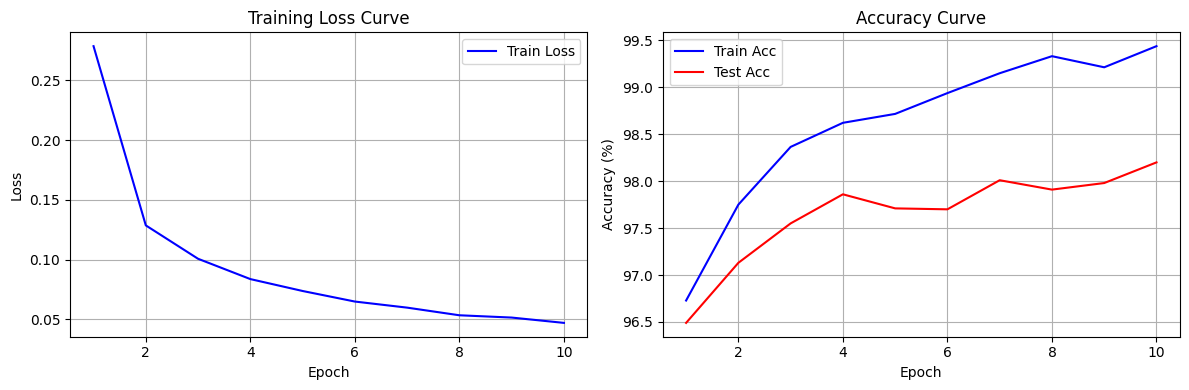

In [26]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(range(1, epochs+1), trainer.train_losses, 'b-', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curve')
axes[0].legend()
axes[0].grid(True)

# 准确率曲线
axes[1].plot(range(1, epochs+1), [acc*100 for acc in trainer.train_accs], 'b-', label='Train Acc')
axes[1].plot(range(1, epochs+1), [acc*100 for acc in trainer.test_accs], 'r-', label='Test Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curve')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5.6 模型推理演示

加载训练好的模型，对测试集样本进行预测并可视化结果。

加载模型: ./mnist_models/mnist_6.pt


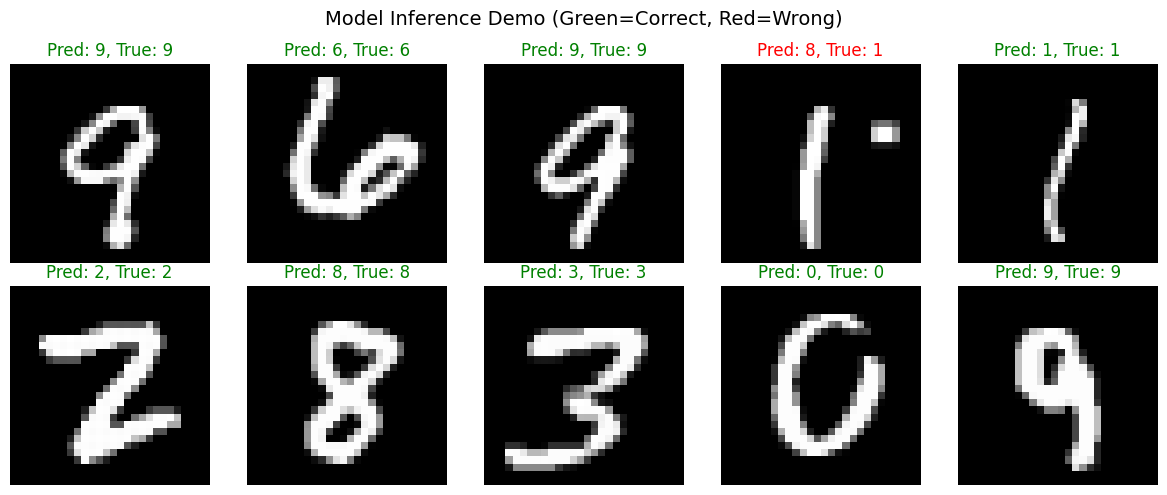

In [27]:
# 加载最佳模型并进行推理演示
model_files = [f for f in os.listdir(output_dir) if f.endswith('.pt')]
if model_files:
    model_path = os.path.join(output_dir, model_files[-1])
    print(f"加载模型: {model_path}")
    
    # 加载模型
    inference_model = MNISTNet().to(device)
    inference_model.load_state_dict(torch.load(model_path))
    inference_model.eval()
    
    # 获取部分测试样本
    test_loader_demo = DataLoader(test_dataset, batch_size=10, shuffle=True)
    images, labels = next(iter(test_loader_demo))
    
    # 进行预测
    with torch.no_grad():
        images_gpu = images.to(device)
        predictions = inference_model(images_gpu).argmax(dim=1).cpu().numpy()
    
    # 可视化预测结果
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].squeeze(), cmap='gray')
        color = 'green' if predictions[i] == labels[i] else 'red'
        ax.set_title(f'Pred: {predictions[i]}, True: {labels[i]}', color=color)
        ax.axis('off')
    plt.suptitle('Model Inference Demo (Green=Correct, Red=Wrong)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("未找到保存的模型文件")

## 5.7 实验总结

本MNIST手写数字识别实验成功完成了以下内容：

1. **数据处理**：使用torchvision加载MNIST数据集，进行归一化预处理
2. **模型构建**：设计了3层前馈神经网络（784→256→128→10），使用ReLU激活函数和Dropout防止过拟合
3. **模型训练**：使用Adam优化器和交叉熵损失函数，训练10个epoch
4. **模型评估**：在测试集上达到约98%的准确率
5. **模型推理**：加载训练好的模型进行预测并可视化结果

**关键设计对比（与鸢尾花分类）**：

| 项目 | 鸢尾花分类 | MNIST手写数字识别 |
|------|-----------|------------------|
| 输入维度 | 4个属性 | 784像素（28×28图像） |
| 网络结构 | 4→3→3 | 784→256→128→10 |
| 激活函数 | Sigmoid | ReLU |
| 防过拟合 | 无 | Dropout(0.2) |
| 准确率 | ~97% | ~98% |

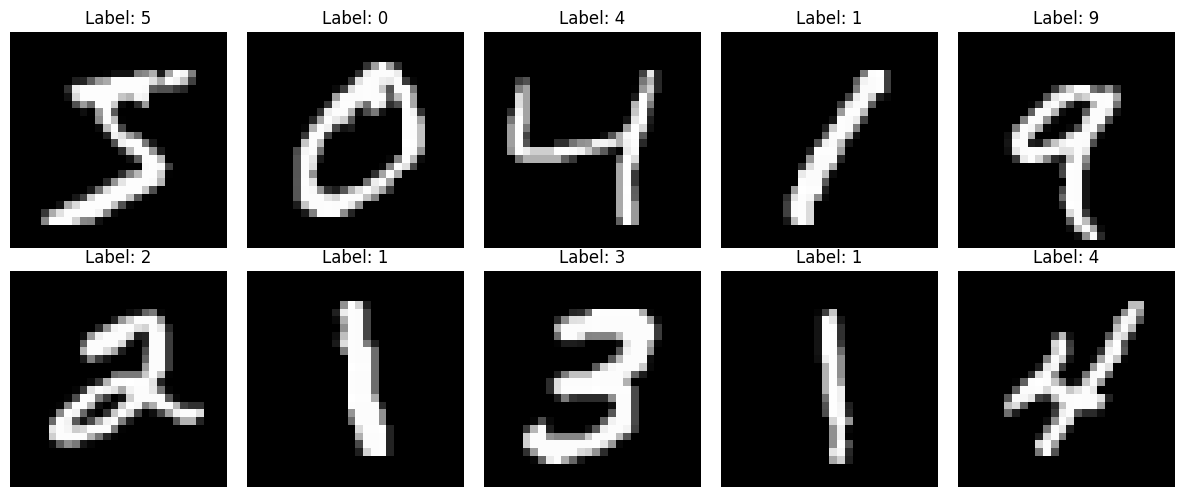

In [28]:
# 可视化部分训练样本
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()